# Distributed Signal Processing Course Project made by: Pablo Bakker and Ines Dos Reis

In [ ]:
# Libraries
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
from utils import *


### Creating the sensor networks

Critical RGG radius for n=64: r_c = 36.05 m
Using communication radius r = 54.08 m
--- Random Geometric Graph ---
  nodes              : 64
  edges              : 993
  connected          : True
  average degree     : 31.03
  lambda_2 : 298.8316
  lambda_max : 1861.4901

--- Regular Grid Graph (4-neighbour) ---
  nodes              : 64
  edges              : 112
  connected          : True
  average degree     : 3.50
  lambda_2 : 2.1749
  lambda_max : 109.9360



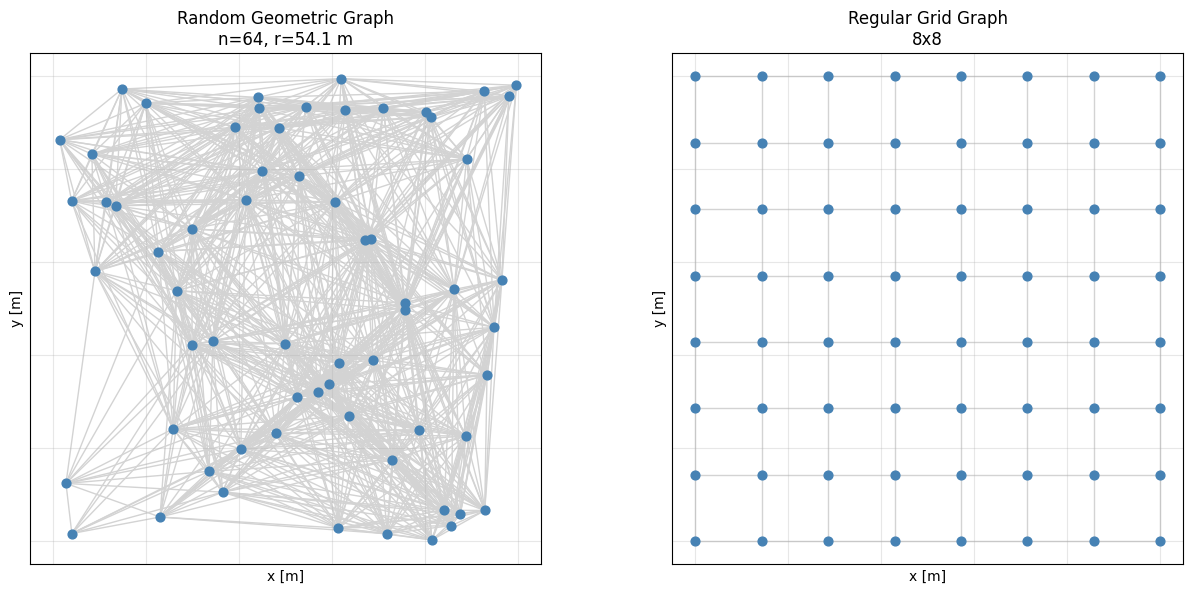

In [10]:
# Parameters
AREA_LENGTH = 100.0    # meters (the 100 x 100 plant)
N_SENSORS = 64       # so we can compare with an 8x8 grid
GRID_SIZE = 8        # sqrt(N_SENSORS)

r_c = critical_radius_rgg(N_SENSORS, AREA_LENGTH)
print(f"Critical RGG radius for n={N_SENSORS}: r_c = {r_c:.2f} m")
COMM_RADIUS = 1.5 * r_c
print(f"Using communication radius r = {COMM_RADIUS:.2f} m")

G_rgg, pos_rgg = random_geometric_network(N_SENSORS, AREA_LENGTH, COMM_RADIUS, seed=0)
G_grid, pos_grid = grid_network(GRID_SIZE, AREA_LENGTH, neighbours="4")

network_summary(G_rgg, name="Random Geometric Graph")
network_summary(G_grid, name="Regular Grid Graph (4-neighbour)")

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
plot_network(G_rgg, pos_rgg, f"Random Geometric Graph\nn={N_SENSORS}, r={COMM_RADIUS:.1f} m", axes[0])
plot_network(G_grid, pos_grid, f"Regular Grid Graph\n{GRID_SIZE}x{GRID_SIZE}", axes[1])
plt.tight_layout()
# plt.savefig("sensor_networks.png", dpi=110, bbox_inches="tight")

### Connectivity analysis


Connectivity experiment with communication radius r = 20 m
Number of Monte Carlo trials per n: 500
-----------------------------------------------------------------
n =  16 | P(connected) = 0.000 | avg degree = 1.56
n =  25 | P(connected) = 0.002 | avg degree = 2.53
n =  36 | P(connected) = 0.032 | avg degree = 3.70
n =  49 | P(connected) = 0.228 | avg degree = 5.05
n =  64 | P(connected) = 0.580 | avg degree = 6.62
n =  81 | P(connected) = 0.810 | avg degree = 8.42
n = 100 | P(connected) = 0.910 | avg degree = 10.39
n = 121 | P(connected) = 0.978 | avg degree = 12.58
n = 144 | P(connected) = 0.986 | avg degree = 15.06
Minimum n reaching 95% connectivity: 121

Connectivity experiment with communication radius r = 25 m
Number of Monte Carlo trials per n: 500
-----------------------------------------------------------------
n =  16 | P(connected) = 0.016 | avg degree = 2.35
n =  25 | P(connected) = 0.110 | avg degree = 3.75
n =  36 | P(connected) = 0.438 | avg degree = 5.52
n =  49 | P(

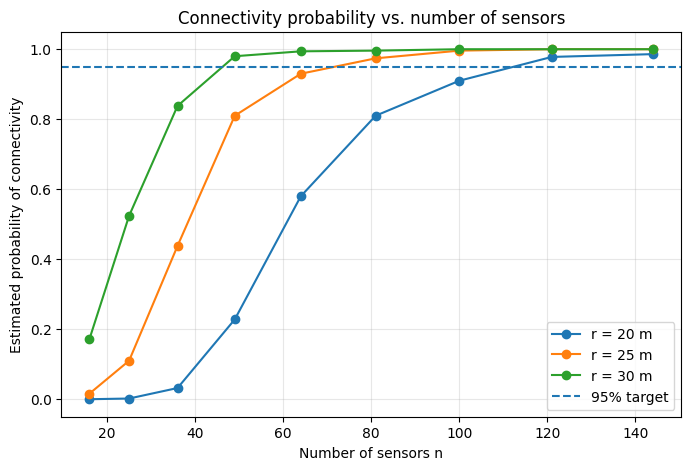

In [11]:
# Connectivity sensitivity experiment: fixed radius -> required n

area_length = 100
comm_radii = [20, 25, 30]          # plausible hardware ranges [m]
n_values = [16, 25, 36, 49, 64, 81, 100, 121, 144]
n_trials = 500
target_probability = 0.95

all_results = {}

for r in comm_radii:
    results = estimate_connectivity_probability(
        n_values=n_values,
        comm_radius=r,
        area_length=area_length,
        n_trials=n_trials
    )
    all_results[r] = results

    print(f"\nConnectivity experiment with communication radius r = {r} m")
    print(f"Number of Monte Carlo trials per n: {n_trials}")
    print("-" * 65)

    required_n = None

    for row in results:
        print(
            f"n = {row['n']:3d} | "
            f"P(connected) = {row['connectivity_probability']:.3f} | "
            f"avg degree = {row['mean_average_degree']:.2f}"
        )

        if required_n is None and row["connectivity_probability"] >= target_probability:
            required_n = row["n"]

    if required_n is not None:
        print(f"Minimum n reaching {target_probability:.0%} connectivity: {required_n}")
    else:
        print(f"No tested n reached {target_probability:.0%} connectivity.")


# Plot all radii on one figure
plt.figure(figsize=(8, 5))

for r, results in all_results.items():
    plt.plot(
        [row["n"] for row in results],
        [row["connectivity_probability"] for row in results],
        marker="o",
        label=f"r = {r} m"
    )

plt.axhline(target_probability, linestyle="--", label="95% target")
plt.xlabel("Number of sensors n")
plt.ylabel("Estimated probability of connectivity")
plt.title("Connectivity probability vs. number of sensors")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## r=25 m and n=81 as the baseline network!

## Randomised Gossip

In [ ]:

def randomized_gossip_average(
    G,
    x0,
    n_iterations=10_000,
    true_average=None,
    packet_loss_prob=0.0,
    seed=None,
    track_every=1,
):
    """
    Randomized pairwise gossip for average consensus.

    At each iteration:
      1. Pick a random edge (i, j)
      2. With probability 1 - packet_loss_prob, nodes i and j exchange values
      3. Both update to their pairwise average

    Parameters
    ----------
    G : networkx.Graph
        Connected communication graph.
    x0 : array-like, shape (n,)
        Initial sensor measurements.
    n_iterations : int
        Number of gossip transmissions.
    true_average : float or None
        If None, computed from x0.
    packet_loss_prob : float
        Bernoulli packet failure probability.
    seed : int or None
        Random seed.
    track_every : int
        Store error every `track_every` iterations.

    Returns
    -------
    x : ndarray
        Final node values.
    errors : ndarray
        Relative consensus error history.
    transmissions : ndarray
        Transmission counts corresponding to errors.
    """

    rng = np.random.default_rng(seed)

    x = np.asarray(x0, dtype=float).copy()
    n = len(x)

    if true_average is None:
        true_average = np.mean(x0)

    edges = list(G.edges())
    if len(edges) == 0:
        raise ValueError("Graph has no edges.")

    errors = []
    transmissions = []

    denom = np.linalg.norm(x0 - true_average)
    if denom == 0:
        denom = 1.0

    for k in range(n_iterations + 1):
        if k % track_every == 0:
            err = np.linalg.norm(x - true_average) / denom
            errors.append(err)
            transmissions.append(k)

        if k == n_iterations:
            break

        i, j = edges[rng.integers(len(edges))]

        # Bernoulli packet loss
        if rng.random() < packet_loss_prob:
            continue

        avg_ij = 0.5 * (x[i] + x[j])
        x[i] = avg_ij
        x[j] = avg_ij

    return x, np.array(errors), np.array(transmissions)

In [7]:
# Initial sensor measurements
rng = np.random.default_rng(1)
x0 = 20 + 5 * rng.standard_normal(G_rgg.number_of_nodes())

x_gossip, errors_gossip, transmissions_gossip = randomized_gossip_average(
    G=G_rgg,
    x0=x0,
    n_iterations=20_000,
    packet_loss_prob=0.0,
    seed=2,
    track_every=10,
)

print("True average:", np.mean(x0))
print("Final average estimate range:", x_gossip.min(), x_gossip.max())
print("Final relative error:", errors_gossip[-1])

True average: 19.633233398791532
Final average estimate range: 19.633233398791532 19.633233398791532
Final relative error: 0.0


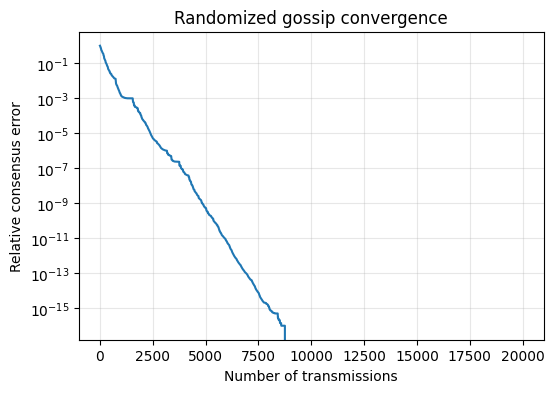

In [8]:
plt.figure(figsize=(6, 4))
plt.semilogy(transmissions_gossip, errors_gossip)
plt.xlabel("Number of transmissions")
plt.ylabel("Relative consensus error")
plt.title("Randomized gossip convergence")
plt.grid(True, which="both", alpha=0.3)
plt.show()